In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import svm

diabetes = load_diabetes()
x_diabetes = diabetes.data
y_diabetes = diabetes.target

display(x_diabetes)

print(f'Dimensão de X: {x_diabetes.shape}')
print(f'Dimensão de Y: {y_diabetes.shape}')

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

Dimensão de X: (442, 10)
Dimensão de Y: (442,)


In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import svm

diabetes = pd.read_csv('/home/nes_pedro/FUND-IA/diabetes.csv')
display(diabetes)

y_diabetes = diabetes['Outcome']
display(y_diabetes)
x_diabetes = diabetes.drop(labels=['Outcome'], axis=1)
display(x_diabetes)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,627.000,50,1
1,1,85,66,29,0,26.6,351.000,31,0
2,8,183,64,0,0,23.3,672.000,32,1
3,1,89,66,23,94,28.1,167.000,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,171.000,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,245.000,30,0
766,1,126,60,0,0,30.1,349.000,47,1


0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,627.000,50
1,1,85,66,29,0,26.6,351.000,31
2,8,183,64,0,0,23.3,672.000,32
3,1,89,66,23,94,28.1,167.000,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,171.000,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,245.000,30
766,1,126,60,0,0,30.1,349.000,47


In [2]:
mediana_target = np.median(y_diabetes)

target_binario = np.where(y_diabetes > mediana_target, 1, 0)

print(f'Mediana: {mediana_target}')
print(f'Quantidade de classes 1: {len(target_binario[target_binario == 1])}')
print(f'Quantidade de classes 0: {len(target_binario[target_binario == 0])}')


Mediana: 0.0
Quantidade de classes 1: 268
Quantidade de classes 0: 500


In [3]:
train_x, test_x, train_y, test_y = train_test_split(x_diabetes, target_binario, random_state=123)

print(f'{len(test_x) / len(train_x):.4f}') # 25% / 75% = 1/3

0.3333


In [4]:
scaler = StandardScaler()

train_x_normalizado = scaler.fit_transform(train_x)
test_x_normalizado = scaler.transform(test_x)

print(train_x_normalizado)
print(test_x_normalizado)

[[-0.53523576  0.78866457 -3.51283337 ... -0.59947313 -1.37232901
  -0.43837617]
 [-0.23504511  1.16612264  0.36926785 ... -0.06319685  2.04284255
  -0.43837617]
 [ 0.36533619 -1.50753871 -0.44801662 ... -0.6910325  -0.29747084
  -0.52405811]
 ...
 [-0.83542642 -0.37516449 -0.44801662 ... -0.87415123  2.42821148
  -1.03814974]
 [ 0.36533619 -0.68971289 -0.75449829 ...  0.25072097  0.62982315
  -0.26701229]
 [ 2.46667076 -1.16153548  0.16494673 ... -0.31171513 -0.18105731
   1.10389873]]
[[ 0.9657175   1.88958395  0.77791008 ...  0.49923925  0.97906374
   1.53230842]
 [-0.53523576  0.19102262 -0.55017717 ... -0.57331332 -1.36686962
  -0.69542199]
 [ 2.1664801   0.53702585  0.36926785 ...  0.1460817  -1.37160644
   0.1613974 ]
 ...
 [-0.53523576 -1.00426128  1.08439176 ...  0.18532142 -0.20112861
   0.76117097]
 [ 0.66552684  1.04030328  0.26710729 ... -0.36403477  1.99467144
   0.50412516]
 [-1.13561707  0.56848069 -0.34585606 ... -1.30578824 -0.54234068
  -1.03814974]]


In [5]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2,
            weights='distance')

knn.fit(train_x_normalizado, train_y)
previsao_knn = knn.predict(test_x_normalizado)

Previsão do modelo: [1 0 1 0 0 1 1 0 1 1 1 0 0 0 1 0 0 0 0 1 1 0 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 1 0 0 0 1 1 0 0 0 1 1 1
 1 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 1 0 0 1
 0 1 0 0 0 0 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1
 0 0 1 1 0 1 0] 

Gabarito: [1 0 0 0 0 1 1 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 1 0 0 1 1 1 0 1 1 0 0 0 1
 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 0 1 0 1 0 0 0 0 1 1 0
 1 0 0 1 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 0 1
 0 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0 1
 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1
 0 0 0 1 0 0 0] 

Acurácia: 71.3542%
Média de Acurácia: 69.0123%
Desvio Padrão: 5.0438%
[[97 22]
 [33 40]]


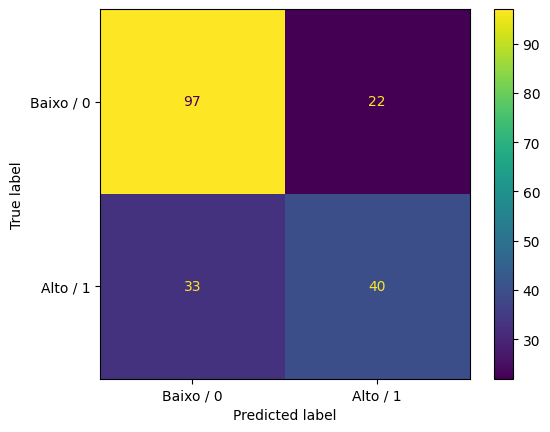

In [6]:
accuracy = np.mean(previsao_knn == test_y)
print(f'Previsão do modelo: {previsao_knn}', '\n')
print(f'Gabarito: {test_y}', '\n')
print(f'Acurácia: {accuracy:.4%}')

scores = cross_val_score(knn, x_diabetes, target_binario, cv=10)

print(f'Média de Acurácia: {np.mean(scores):.4%}')
print(f'Desvio Padrão: {np.std(scores):.4%}')

matriz_confusao = confusion_matrix(test_y, previsao_knn)
print(matriz_confusao)
plot_matriz = ConfusionMatrixDisplay(matriz_confusao, display_labels=['Baixo / 0', 'Alto / 1'])
plot_matriz.plot()

Previsão do modelo: [1 0 1 1 1 0 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 0 0 0 1 0 0 1 1 0 1 1 1 1 0 0
 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 1 1 1 0 0 1 1 1 0 0 1 0 0 0 0 0 1
 0 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 1 0 1 1 0 1 0 1 0 0 0 0 0 1 1 0 0 1 1 1 0] 

Gabarito: [1 1 1 1 0 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 1 1 0 1 1 1 1 0 0
 0 1 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 1 1
 0 0 1 0 0 0 0 1 1 1 1 1 1 0 1 1 0 0 0 1 0 1 1 0 0 1 0 0 1 0 1 0 0 1 1 1 0] 

Acurácia: 74.7748%
Média de Acurácia: 74.1931%
Desvio Padrão: 6.4735%
[[43 14]
 [14 40]]


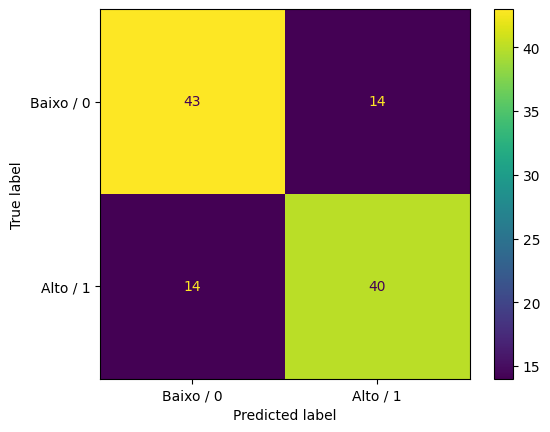

In [9]:
svm_modelo = svm.SVC(kernel='linear', C=1.0)
svm_modelo.fit(train_x_normalizado, train_y)
previsoes_svm_modelo = svm_modelo.predict(test_x_normalizado)

accuracy_svm_modelo = np.mean(previsoes_svm_modelo == test_y)
print(f'Previsão do modelo: {previsoes_svm_modelo}', '\n')
print(f'Gabarito: {test_y}', '\n')
print(f'Acurácia: {accuracy_svm_modelo:.4%}')

cross = cross_val_score(svm_modelo, x_diabetes, target_binario)

print(f'Média de Acurácia: {np.mean(cross):.4%}')
print(f'Desvio Padrão: {np.std(cross):.4%}')

matriz_confusao = confusion_matrix(test_y, previsoes_svm_modelo)
print(matriz_confusao)
plot_matriz = ConfusionMatrixDisplay(matriz_confusao, display_labels=['Baixo / 0', 'Alto / 1'])
plot_matriz.plot()

In [10]:
"""O svm teve melhores resultados, tendo mais acertos e uma média de acurácia maior, 
perdendo apenas no desvio padrão das validações cruzadas."""

'O svm teve melhores resultados, tendo mais acertos e uma média de acurácia maior, \nperdendo apenas no desvio padrão das validações cruzadas.'

In [11]:
print(diabetes.feature_names)
novo_teste = np.array([[0.05, 0.05, 0.03, 0.02, -0.01, -0.02, 0.01, 0.03, 0.04, 0.02]])
novo_teste_normalizado = scaler.transform(novo_teste)

predict_svm = svm_modelo.predict(novo_teste_normalizado)
predict_knn = knn.predict(novo_teste_normalizado)

print(f'Previsão SVM : {predict_svm}')
print(f'Previsão KNN : {predict_knn}')

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Previsão SVM : [1]
Previsão KNN : [1]
